In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt
from src import dataset
import tensorflow as tf
import json
import numpy as np

(224, 224, 3)


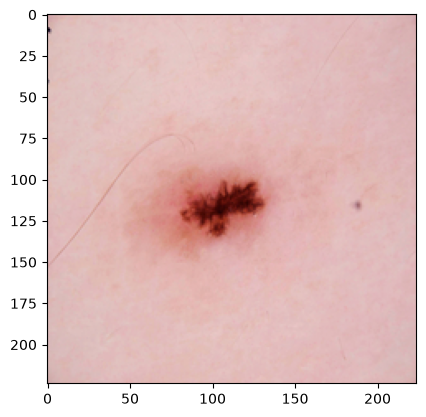

In [2]:
img=plt.imread("../datasets/fanconic/skin-cancer-malignant-vs-benign/versions/4/test/benign/1.jpg")
plt.imshow(img/255)
print(img.shape)


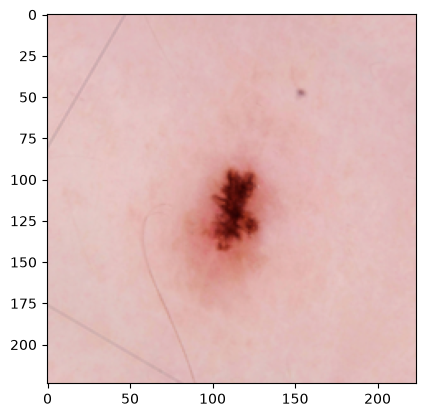

In [3]:
img=plt.imread("../datasets/fanconic/skin-cancer-malignant-vs-benign/versions/4/test/benign/1.jpg")
augemented_image=dataset.data_augmenter()(tf.expand_dims(img,0))
plt.imshow(augemented_image[0]/255)

## Fist stage : tuning the top layer

In [4]:
with open("first_fit.json","r")  as f: 
    a=json.load(f)
print(a)

{'accuracy': [0.735071063041687, 0.8175355195999146, 0.828436017036438, 0.8478673100471497, 0.849763035774231, 0.8616113662719727, 0.8616113662719727, 0.8668246269226074, 0.8687203526496887, 0.8838862776756287, 0.8824644684791565, 0.8829383850097656, 0.8824644684791565, 0.8900473713874817, 0.8872038125991821, 0.8933649063110352, 0.8966824412345886, 0.9028435945510864, 0.9033175110816956, 0.8999999761581421, 0.9099525809288025], 'auc': [0.8180784583091736, 0.8967803120613098, 0.9144838452339172, 0.9278388619422913, 0.930500864982605, 0.9342769980430603, 0.9448973536491394, 0.9456766843795776, 0.9459940195083618, 0.9541747570037842, 0.9514205455780029, 0.9562178254127502, 0.9563974142074585, 0.9591474533081055, 0.9583283066749573, 0.961965799331665, 0.964007556438446, 0.9657226204872131, 0.9665380120277405, 0.9656741619110107, 0.9687420725822449], 'false_negatives': [303.0, 197.0, 188.0, 163.0, 166.0, 152.0, 161.0, 146.0, 145.0, 127.0, 135.0, 125.0, 125.0, 111.0, 119.0, 120.0, 106.0, 111

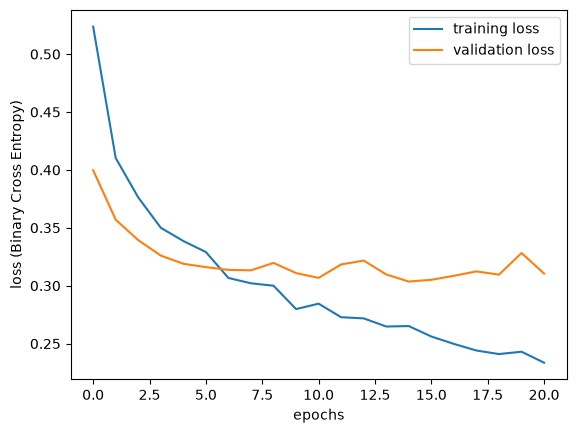

In [5]:

plt.plot(np.arange(len(a["loss"])),a["loss"],label="training loss")
plt.plot(np.arange(len(a["val_loss"])),a["val_loss"],label='validation loss')
plt.xlabel("epochs")
plt.ylabel("loss (Binary Cross Entropy)")
plt.legend()

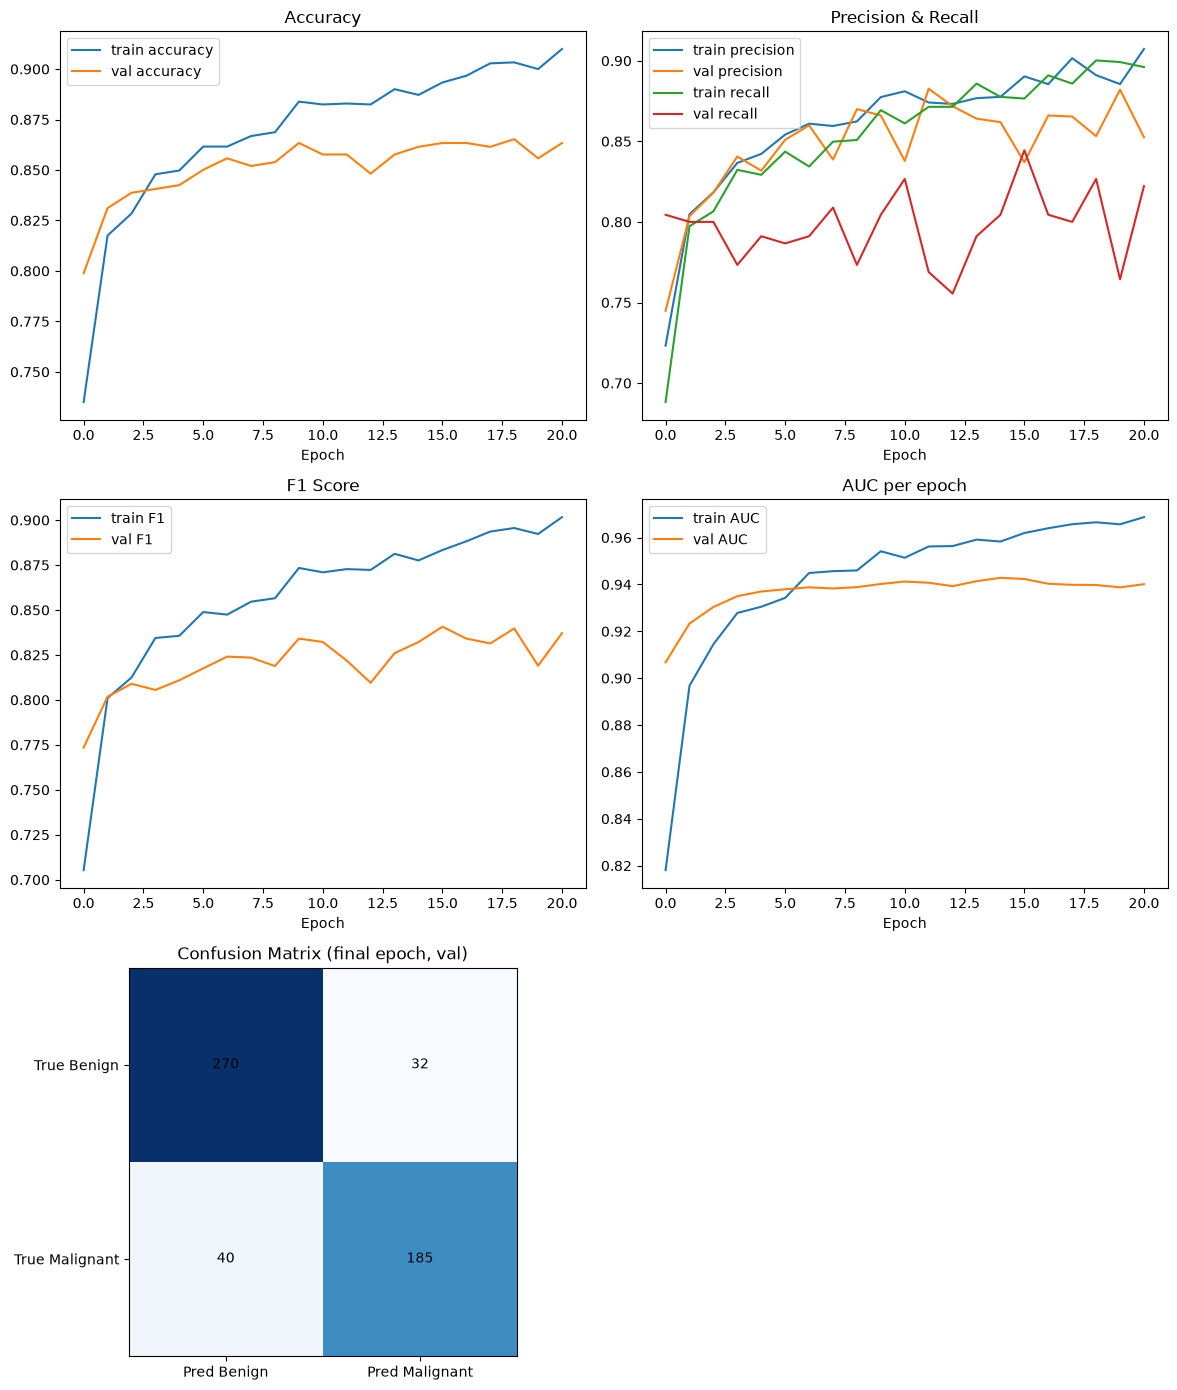

In [8]:

fig, ax = plt.subplots(3, 2, figsize=(12, 14))

# --- Accuracy ---
ax[0,0].plot(a["accuracy"], label="train accuracy")
ax[0,0].plot(a["val_accuracy"], label="val accuracy")
ax[0,0].set_title("Accuracy")
ax[0,0].set_xlabel("Epoch")
ax[0,0].legend()

# --- Precision & Recall ---
ax[0,1].plot(a["precision"], label="train precision")
ax[0,1].plot(a["val_precision"], label="val precision")
ax[0,1].plot(a["recall"], label="train recall")
ax[0,1].plot(a["val_recall"], label="val recall")
ax[0,1].set_title("Precision & Recall")
ax[0,1].set_xlabel("Epoch")
ax[0,1].legend()

# --- F1 score ---
train_f1 = (2 * np.array(a["precision"]) * np.array(a["recall"])) / \
           (np.array(a["precision"]) + np.array(a["recall"]) + 1e-8)
val_f1 = (2 * np.array(a["val_precision"]) * np.array(a["val_recall"])) / \
         (np.array(a["val_precision"]) + np.array(a["val_recall"]) + 1e-8)

ax[1,0].plot(train_f1, label="train F1")
ax[1,0].plot(val_f1, label="val F1")
ax[1,0].set_title("F1 Score")
ax[1,0].set_xlabel("Epoch")
ax[1,0].legend()

# --- AUC ---
ax[1,1].plot(a["auc"], label="train AUC")
ax[1,1].plot(a["val_auc"], label="val AUC")
ax[1,1].set_title("AUC per epoch")
ax[1,1].set_xlabel("Epoch")
ax[1,1].legend()

# --- Confusion matrix from final epoch (validation) ---
tp = a["val_true_positives"][-1]
tn = a["val_true_negatives"][-1]
fp = a["val_false_positives"][-1]
fn = a["val_false_negatives"][-1]

cm = np.array([[tn, fp], [fn, tp]])
im = ax[2,0].imshow(cm, cmap="Blues")
ax[2,0].set_title("Confusion Matrix (final epoch, val)")
ax[2,0].set_xticks([0,1]); ax[2,0].set_xticklabels(["Pred Benign","Pred Malignant"])
ax[2,0].set_yticks([0,1]); ax[2,0].set_yticklabels(["True Benign","True Malignant"])
for i in range(2):
    for j in range(2):
        ax[2,0].text(j, i, int(cm[i,j]), ha="center", va="center", color="black")

ax[2,1].axis("off")  # empty slot, or use it for a loss curve if you have "loss"/"val_loss"

plt.tight_layout()
plt.show()
plt.show()

In [7]:
metrics = ["accuracy", "precision", "recall", "auc",
           "true_positives", "true_negatives",
           "false_positives", "false_negatives"]

for m in metrics:
    train_val = a[m][-1]
    val_val = a[f"val_{m}"][-1]
    print(f"{m:20s} | train: {train_val:.4f} | val: {val_val:.4f}")

# F1 score (computed, not directly in history)
train_f1_last = (2 * a["precision"][-1] * a["recall"][-1]) / \
                (a["precision"][-1] + a["recall"][-1] + 1e-8)
val_f1_last = (2 * a["val_precision"][-1] * a["val_recall"][-1]) / \
              (a["val_precision"][-1] + a["val_recall"][-1] + 1e-8)

print(f"{'f1_score':20s} | train: {train_f1_last:.4f} | val: {val_f1_last:.4f}")

accuracy             | train: 0.9100 | val: 0.8634
precision            | train: 0.9073 | val: 0.8525
recall               | train: 0.8961 | val: 0.8222
auc                  | train: 0.9687 | val: 0.9401
true_positives       | train: 871.0000 | val: 185.0000
true_negatives       | train: 1049.0000 | val: 270.0000
false_positives      | train: 89.0000 | val: 32.0000
false_negatives      | train: 101.0000 | val: 40.0000
f1_score             | train: 0.9017 | val: 0.8371


## Second layers : tuning last layers

In [ ]:
with open("second_fit.json","r")  as f: 
    a=json.load(f)
print(a)

In [ ]:

plt.plot(np.arange(len(a["loss"])),a["loss"],label="training loss")
plt.plot(np.arange(len(a["val_loss"])),a["val_loss"],label='validation loss')
plt.xlabel("epochs")
plt.ylabel("loss (Binary Cross Entropy)")
plt.legend()

In [ ]:

fig, ax = plt.subplots(3, 2, figsize=(12, 14))

# --- Accuracy ---
ax[0,0].plot(a["accuracy"], label="train accuracy")
ax[0,0].plot(a["val_accuracy"], label="val accuracy")
ax[0,0].set_title("Accuracy")
ax[0,0].set_xlabel("Epoch")
ax[0,0].legend()

# --- Precision & Recall ---
ax[0,1].plot(a["precision"], label="train precision")
ax[0,1].plot(a["val_precision"], label="val precision")
ax[0,1].plot(a["recall"], label="train recall")
ax[0,1].plot(a["val_recall"], label="val recall")
ax[0,1].set_title("Precision & Recall")
ax[0,1].set_xlabel("Epoch")
ax[0,1].legend()

# --- F1 score ---
train_f1 = (2 * np.array(a["precision"]) * np.array(a["recall"])) / \
           (np.array(a["precision"]) + np.array(a["recall"]) + 1e-8)
val_f1 = (2 * np.array(a["val_precision"]) * np.array(a["val_recall"])) / \
         (np.array(a["val_precision"]) + np.array(a["val_recall"]) + 1e-8)

ax[1,0].plot(train_f1, label="train F1")
ax[1,0].plot(val_f1, label="val F1")
ax[1,0].set_title("F1 Score")
ax[1,0].set_xlabel("Epoch")
ax[1,0].legend()

# --- AUC ---
ax[1,1].plot(a["auc"], label="train AUC")
ax[1,1].plot(a["val_auc"], label="val AUC")
ax[1,1].set_title("AUC per epoch")
ax[1,1].set_xlabel("Epoch")
ax[1,1].legend()

# --- Confusion matrix from final epoch (validation) ---
tp = a["val_true_positives"][-1]
tn = a["val_true_negatives"][-1]
fp = a["val_false_positives"][-1]
fn = a["val_false_negatives"][-1]

cm = np.array([[tn, fp], [fn, tp]])
im = ax[2,0].imshow(cm, cmap="Blues")
ax[2,0].set_title("Confusion Matrix (final epoch, val)")
ax[2,0].set_xticks([0,1]); ax[2,0].set_xticklabels(["Pred Benign","Pred Malignant"])
ax[2,0].set_yticks([0,1]); ax[2,0].set_yticklabels(["True Benign","True Malignant"])
for i in range(2):
    for j in range(2):
        ax[2,0].text(j, i, int(cm[i,j]), ha="center", va="center", color="black")

ax[2,1].axis("off")  # empty slot, or use it for a loss curve if you have "loss"/"val_loss"

plt.tight_layout()
plt.show()
plt.show()